In [1]:
import pandas as pd

In [2]:
cleaned_matches_stacked = pd.read_csv('./Data/cleaned_matches_stacked.csv')
cleaned_matches_stacked.head()

,game_id,date,location,team,opp,score,opp_score,elo,opp_elo,elo_diff,result_class
0,2016-01-03IndiaAfghanistan,2016-01-03,South Asian Championship in India,India,Afghanistan,2,1,1063,1143,-80,T1
1,2016-01-03IndiaAfghanistan,2016-01-03,South Asian Championship in India,Afghanistan,India,1,2,1143,1063,80,T2
2,2016-01-06EstoniaSweden,2016-01-06,Friendly in the United Arab Emirates,Estonia,Sweden,1,1,1494,1767,-273,D
3,2016-01-06EstoniaSweden,2016-01-06,Friendly in the United Arab Emirates,Sweden,Estonia,1,1,1767,1494,273,D
4,2016-01-08BangladeshSri Lanka,2016-01-08,Bangabandhu Gold Cup in Bangladesh,Bangladesh,Sri Lanka,4,2,890,775,115,T1


In [32]:
cleaned_matches_stacked[cleaned_matches_stacked['team'] == 'India']

,game_id,date,location,team,opp,score,opp_score,elo,opp_elo,elo_diff,result_class,outcome
0,2016-01-03IndiaAfghanistan,2016-01-03,South Asian Championship in India,India,Afghanistan,2,1,1063,1143,-80,T1,1
133,2016-03-24IranIndia,2016-03-24,World Cup and Asian Cup qualifier in Iran,India,Iran,0,4,1082,1727,-645,T2,-1
338,2016-03-29IndiaTurkmenistan,2016-03-29,World Cup and Asian Cup qualifier in India,India,Turkmenistan,1,2,1081,1270,-189,T2,-1
586,2016-06-02LaosIndia,2016-06-02,Asian Cup qualifier in Laos,India,Laos,1,0,1066,812,254,T1,1
768,2016-06-07IndiaLaos,2016-06-07,Asian Cup qualifier in India,India,Laos,6,1,1078,800,278,T1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
15867,2024-06-11QatarIndia,2024-06-11,World Cup and Asian Cup qualifier in Qatar,India,Qatar,1,2,1196,1629,-433,T2,-1
16159,2024-09-03IndiaMauritius,2024-09-03,Friendly tournament in India,India,Mauritius,0,0,1194,1037,157,D,0
16414,2024-09-09IndiaSyria,2024-09-09,Friendly tournament in India,India,Syria,0,3,1185,1422,-237,T2,-1
16737,2024-10-12VietnamIndia,2024-10-12,Friendly in Vietnam,India,Vietnam,1,1,1169,1253,-84,D,0


<Axes: >

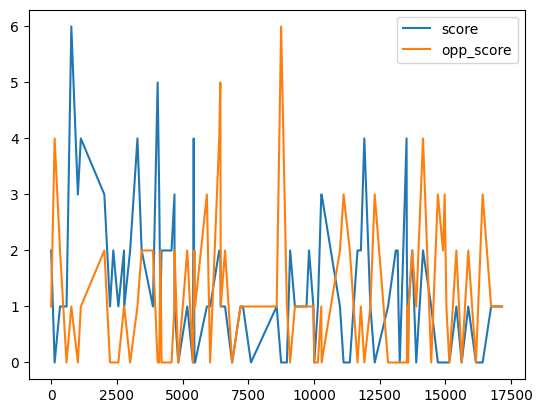

In [33]:
cleaned_matches_stacked[cleaned_matches_stacked['team'] == 'India'][['score', 'opp_score']].plot()

In [34]:
cleaned_matches_stacked['score'].corr(cleaned_matches_stacked['opp_score'])

-0.21429302681232737

In [3]:
print(cleaned_matches_stacked['date'].min())
print(cleaned_matches_stacked['date'].max())

2016-01-03
2025-01-22


In [4]:
def num_outcome(row):
    if row['result_class'] == 'T1':
        val = 1
    elif row['result_class'] == 'D':
        val = 0
    elif row['result_class'] == 'T2':
        val = -1
    else:
        raise Exception
    return val

# Predict Win, Tie, Loss

In [46]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
import optuna

# Configuration
SEED = 42
NUM_EPOCHS = 10
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set random seeds
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

# Import data
# game_id,date,location,team,opp,score,opp_score,elo,opp_elo,elo_diff,result_class
data = pd.read_csv('./Data/cleaned_matches_stacked.csv')

# Convert result to numeric
data['outcome'] = data.apply(num_outcome, axis=1) + 1
# data['outcome'] = data['result_class']

# Preprocessing
le = LabelEncoder()
data['team'] = le.fit_transform(data['team'])
data['opp'] = le.transform(data['opp'])

# Split features and target
X = data[['team', 'opp', 'elo', 'opp_elo', 'elo_diff']] #'score', 'opp_score', 
y = data['outcome']

n = len(data[data['date'] < '2024-01-01'])

# Split data on time
X_train, X_val, y_train, y_val = X[:n], X[n:], y[:n], y[n:]

# Dataset class
class SportsDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return {
            'team': torch.tensor(self.features.iloc[idx]['team'], dtype=torch.long),
            'opp': torch.tensor(self.features.iloc[idx]['opp'], dtype=torch.long),
            'numerical': torch.tensor(self.features.iloc[idx][['elo', 'opp_elo', 'elo_diff']], dtype=torch.float),
            'labels': torch.tensor(self.labels.iloc[idx], dtype=torch.long)
        }

# Create dataloaders
train_dataset = SportsDataset(X_train, y_train)
val_dataset = SportsDataset(X_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Transformer model
class SportsTransformer(nn.Module):
    def __init__(self, num_teams, numerical_features, embedding_dim=64, 
                 num_heads=4, num_layers=3, dropout=0.1):
        super().__init__()
        self.team_embedding = nn.Embedding(num_teams, embedding_dim)
        self.numerical_projection = nn.Linear(numerical_features, embedding_dim)
        
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=embedding_dim,
                nhead=num_heads,
                dim_feedforward=embedding_dim*4,
                dropout=dropout,
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.classifier = nn.Linear(embedding_dim, 3)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, team, opp, numerical):
        # Embed categorical features
        team1_emb = self.team_embedding(team)
        team2_emb = self.team_embedding(opp)
        
        # Project numerical features
        num_emb = self.numerical_projection(numerical)
        
        # Combine features
        combined = torch.stack([team1_emb, team2_emb, num_emb], dim=1)
        
        # Transformer processing
        transformer_out = self.transformer(combined)
        
        # Classification
        pooled = torch.mean(transformer_out, dim=1)
        return self.classifier(self.dropout(pooled))

# Training function
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=10):
    model.to(DEVICE)
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        
        for batch in train_loader:
            optimizer.zero_grad()
            
            inputs = {k: v.to(DEVICE) for k, v in batch.items() if k != 'labels'}
            labels = batch['labels'].to(DEVICE)
            
            outputs = model(**inputs)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * labels.size(0)
        
        # Validation
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch in val_loader:
                inputs = {k: v.to(DEVICE) for k, v in batch.items() if k != 'labels'}
                labels = batch['labels'].to(DEVICE)
                
                outputs = model(**inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * labels.size(0)
                all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        # Calculate metrics
        train_loss = train_loss / len(train_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = (np.array(all_preds) == np.array(all_labels)).mean()
        
        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')
    
    return model

# Hyperparameter optimization with Optuna
def objective(trial):
    params = {
        'embedding_dim': trial.suggest_categorical('embedding_dim', [32, 64, 128]),
        'num_heads': trial.suggest_categorical('num_heads', [2, 4, 8]),
        'num_layers': trial.suggest_int('num_layers', 1, 4),
        'learning_rate': trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True),
        'dropout': trial.suggest_float('dropout', 0.1, 0.5)
    }
    
    model = SportsTransformer(
        num_teams=len(le.classes_),
        numerical_features=3,
        embedding_dim=params['embedding_dim'],
        num_heads=params['num_heads'],
        num_layers=params['num_layers'],
        dropout=params['dropout']
    )
    
    optimizer = optim.AdamW(model.parameters(), lr=params['learning_rate'])
    criterion = nn.CrossEntropyLoss()
    
    # Reduced number of epochs for faster tuning
    model = train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=5)
    
    # Evaluate final validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            inputs = {k: v.to(DEVICE) for k, v in batch.items() if k != 'labels'}
            labels = batch['labels'].to(DEVICE)
            outputs = model(**inputs)
            val_loss += criterion(outputs, labels).item()
    
    return val_loss / len(val_loader)

In [6]:
# Run optimization
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

# Train final model with best parameters
best_params = study.best_params
print("Best hyperparameters:", best_params)

[I 2025-01-30 21:01:52,630] A new study created in memory with name: no-name-51486284-f4de-4e72-b8dd-e4ec26cabf74


Epoch 1/5
Train Loss: 1.0388 | Val Loss: 0.9338 | Val Acc: 0.5691
Epoch 2/5
Train Loss: 0.9431 | Val Loss: 0.9353 | Val Acc: 0.5730
Epoch 3/5
Train Loss: 0.9394 | Val Loss: 0.9349 | Val Acc: 0.5722
Epoch 4/5
Train Loss: 0.9325 | Val Loss: 0.9381 | Val Acc: 0.5734
Epoch 5/5
Train Loss: 0.9324 | Val Loss: 0.9313 | Val Acc: 0.5718


[I 2025-01-30 21:02:26,858] Trial 0 finished with value: 0.931552215858742 and parameters: {'embedding_dim': 64, 'num_heads': 8, 'num_layers': 4, 'learning_rate': 2.6996664628421506e-05, 'dropout': 0.23052752156497222}. Best is trial 0 with value: 0.931552215858742.


Epoch 1/5
Train Loss: 1.0214 | Val Loss: 0.9528 | Val Acc: 0.5710
Epoch 2/5
Train Loss: 0.9534 | Val Loss: 0.9400 | Val Acc: 0.5730
Epoch 3/5
Train Loss: 0.9404 | Val Loss: 0.9390 | Val Acc: 0.5699
Epoch 4/5
Train Loss: 0.9351 | Val Loss: 0.9315 | Val Acc: 0.5741
Epoch 5/5
Train Loss: 0.9322 | Val Loss: 0.9293 | Val Acc: 0.5745


[I 2025-01-30 21:02:59,954] Trial 1 finished with value: 0.929586935190507 and parameters: {'embedding_dim': 32, 'num_heads': 8, 'num_layers': 3, 'learning_rate': 0.0003047901170546249, 'dropout': 0.4465673733035317}. Best is trial 1 with value: 0.929586935190507.


...

Epoch 1/5
Train Loss: 0.9408 | Val Loss: 0.9226 | Val Acc: 0.5730
Epoch 2/5
Train Loss: 0.9196 | Val Loss: 0.9266 | Val Acc: 0.5691
Epoch 3/5
Train Loss: 0.9161 | Val Loss: 0.9254 | Val Acc: 0.5722
Epoch 4/5
Train Loss: 0.9138 | Val Loss: 0.9243 | Val Acc: 0.5753
Epoch 5/5
Train Loss: 0.9148 | Val Loss: 0.9304 | Val Acc: 0.5718


[I 2025-01-30 21:06:22,011] Trial 8 finished with value: 0.9307057427035438 and parameters: {'embedding_dim': 32, 'num_heads': 8, 'num_layers': 1, 'learning_rate': 0.0007922511710401307, 'dropout': 0.19435801900296046}. Best is trial 4 with value: 0.9261518032462509.


Epoch 1/5
Train Loss: 0.9549 | Val Loss: 0.9461 | Val Acc: 0.5734
Epoch 2/5
Train Loss: 0.9265 | Val Loss: 0.9324 | Val Acc: 0.5714
Epoch 3/5
Train Loss: 0.9221 | Val Loss: 0.9396 | Val Acc: 0.5734
Epoch 4/5
Train Loss: 0.9185 | Val Loss: 0.9329 | Val Acc: 0.5730
Epoch 5/5
Train Loss: 0.9178 | Val Loss: 0.9341 | Val Acc: 0.5730


[I 2025-01-30 21:06:50,250] Trial 9 finished with value: 0.9344492297113678 and parameters: {'embedding_dim': 128, 'num_heads': 8, 'num_layers': 1, 'learning_rate': 8.311920110832527e-05, 'dropout': 0.2955621488473946}. Best is trial 4 with value: 0.9261518032462509.


Best hyperparameters: {'embedding_dim': 32, 'num_heads': 4, 'num_layers': 3, 'learning_rate': 0.00016984498277178176, 'dropout': 0.2810897998465155}


In [9]:
final_model = SportsTransformer(
    num_teams=len(le.classes_),
    numerical_features=3,
    embedding_dim=best_params['embedding_dim'],
    num_heads=best_params['num_heads'],
    num_layers=best_params['num_layers'],
    dropout=best_params['dropout']
)

optimizer = optim.AdamW(final_model.parameters(), lr=best_params['learning_rate'])
criterion = nn.CrossEntropyLoss()

final_model = train_model(final_model, train_loader, val_loader, optimizer, criterion, num_epochs=NUM_EPOCHS)

Epoch 1/10
Train Loss: 0.9816 | Val Loss: 0.9346 | Val Acc: 0.5722
Epoch 2/10
Train Loss: 0.9402 | Val Loss: 0.9276 | Val Acc: 0.5749
Epoch 3/10
Train Loss: 0.9286 | Val Loss: 0.9337 | Val Acc: 0.5722
Epoch 4/10
Train Loss: 0.9259 | Val Loss: 0.9262 | Val Acc: 0.5734
Epoch 5/10
Train Loss: 0.9262 | Val Loss: 0.9254 | Val Acc: 0.5726
Epoch 6/10
Train Loss: 0.9227 | Val Loss: 0.9212 | Val Acc: 0.5734
Epoch 7/10
Train Loss: 0.9237 | Val Loss: 0.9269 | Val Acc: 0.5734
Epoch 8/10
Train Loss: 0.9207 | Val Loss: 0.9191 | Val Acc: 0.5714
Epoch 9/10
Train Loss: 0.9200 | Val Loss: 0.9242 | Val Acc: 0.5730
Epoch 10/10
Train Loss: 0.9202 | Val Loss: 0.9254 | Val Acc: 0.5695


In [10]:
# Evaluation
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            inputs = {k: v.to(DEVICE) for k, v in batch.items() if k != 'labels'}
            labels = batch['labels'].cpu().numpy()
            
            outputs = model(**inputs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            
            all_preds.extend(preds)
            all_labels.extend(labels)
    
    print(classification_report(all_labels, all_preds))

print("Validation set evaluation:")
evaluate_model(final_model, val_loader)

Validation set evaluation:
              precision    recall  f1-score   support

           0       0.60      0.72      0.65       968
           1       0.00      0.00      0.00       654
           2       0.55      0.80      0.65       968

    accuracy                           0.57      2590
   macro avg       0.38      0.51      0.43      2590
weighted avg       0.43      0.57      0.49      2590



/home/cbreece/miniconda3/envs/darts/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/cbreece/miniconda3/envs/darts/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/cbreece/miniconda3/envs/darts/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(r

# Predict score

In [47]:
# Key changes needed for regression:
# 1. Output layer and loss function
# 2. Label preprocessing
# 3. Evaluation metrics
# 4. Data loading modifications

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna

# Configuration
SEED = 42
NUM_EPOCHS = 10
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Import data
# game_id,date,location,team,opp,score,opp_score,elo,opp_elo,elo_diff,result_class
data = pd.read_csv('./Data/cleaned_matches_stacked.csv')
data[['team1_elo','team2_elo']] = data[['elo','opp_elo']]

# Create target variable (score difference)
data['score_diff'] = data['score'] - data['opp_score']

# Preprocessing
le = LabelEncoder()
data['team1'] = le.fit_transform(data['team'])
data['team2'] = le.transform(data['opp'])

# Split features and target
X = data[['team1', 'team2', 'team1_elo', 'team2_elo', 'elo_diff']]
y = data['score_diff'].values  # Regression target

# Split data
X_train, X_val, y_train, y_val = X[:n], X[n:], y[:n], y[n:]

# Dataset class modification
class SportsDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features.reset_index(drop=True)
        self.labels = labels
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return {
            'team1': torch.tensor(self.features.iloc[idx]['team1'], dtype=torch.long),
            'team2': torch.tensor(self.features.iloc[idx]['team2'], dtype=torch.long),
            'numerical': torch.tensor(self.features.iloc[idx][['team1_elo', 'team2_elo', 'elo_diff']], 
                                    dtype=torch.float),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float)  # Changed to float
        }

# Create dataloaders
train_dataset = SportsDataset(X_train, y_train)
val_dataset = SportsDataset(X_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Model modification
class SportsTransformer(nn.Module):
    def __init__(self, num_teams, numerical_features, embedding_dim=64, 
                 num_heads=4, num_layers=3, dropout=0.1):
        super().__init__()
        self.team_embedding = nn.Embedding(num_teams, embedding_dim)
        self.numerical_projection = nn.Linear(numerical_features, embedding_dim)
        
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=embedding_dim,
                nhead=num_heads,
                dim_feedforward=embedding_dim*4,
                dropout=dropout,
                batch_first=True
            ),
            num_layers=num_layers
        )
        # Single output for regression
        self.regressor = nn.Linear(embedding_dim, 1)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, team1, team2, numerical):
        team1_emb = self.team_embedding(team1)
        team2_emb = self.team_embedding(team2)
        num_emb = self.numerical_projection(numerical)
        
        combined = torch.stack([team1_emb, team2_emb, num_emb], dim=1)
        transformer_out = self.transformer(combined)
        pooled = torch.mean(transformer_out, dim=1)
        return self.regressor(self.dropout(pooled)).squeeze()

# Training function modification
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=10):
    model.to(DEVICE)
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        
        for batch in train_loader:
            optimizer.zero_grad()
            
            inputs = {k: v.to(DEVICE) for k, v in batch.items() if k != 'labels'}
            labels = batch['labels'].to(DEVICE)
            
            outputs = model(**inputs)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * labels.size(0)
        
        # Validation
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch in val_loader:
                inputs = {k: v.to(DEVICE) for k, v in batch.items() if k != 'labels'}
                labels = batch['labels'].cpu().numpy()
                
                outputs = model(**inputs).cpu().numpy()
                loss = criterion(torch.tensor(outputs), torch.tensor(labels))
                
                val_loss += loss.item() * labels.shape[0]
                all_preds.extend(outputs)
                all_labels.extend(labels)
        
        # Calculate metrics
        train_loss = train_loss / len(train_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)
        mae = mean_absolute_error(all_labels, all_preds)
        rmse = np.sqrt(mean_squared_error(all_labels, all_preds))
        
        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
        print(f'MAE: {mae:.4f} | RMSE: {rmse:.4f}')
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model_regression.pth')
    
    return model

# Evaluation function modification
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            inputs = {k: v.to(DEVICE) for k, v in batch.items() if k != 'labels'}
            labels = batch['labels'].cpu().numpy()
            
            outputs = model(**inputs).cpu().numpy()
            
            all_preds.extend(outputs)
            all_labels.extend(labels)
    
    print(f"MAE: {mean_absolute_error(all_labels, all_preds):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(all_labels, all_preds)):.4f}")
    print(f"R²: {r2_score(all_labels, all_preds):.4f}")

# Hyperparameter optimization modification
def objective(trial):
    params = {
        'embedding_dim': trial.suggest_categorical('embedding_dim', [32, 64, 128]),
        'num_heads': trial.suggest_categorical('num_heads', [2, 4, 8]),
        'num_layers': trial.suggest_int('num_layers', 1, 4),
        'learning_rate': trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True),
        'dropout': trial.suggest_float('dropout', 0.1, 0.5)
    }
    
    model = SportsTransformer(
        num_teams=len(le.classes_),
        numerical_features=3,
        embedding_dim=params['embedding_dim'],
        num_heads=params['num_heads'],
        num_layers=params['num_layers'],
        dropout=params['dropout']
    )
    
    optimizer = optim.AdamW(model.parameters(), lr=params['learning_rate'])
    criterion = nn.MSELoss()  # Changed to MSE loss
    
    model = train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=5)
    
    # Evaluate final validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            inputs = {k: v.to(DEVICE) for k, v in batch.items() if k != 'labels'}
            labels = batch['labels'].to(DEVICE)
            outputs = model(**inputs)
            val_loss += criterion(outputs, labels).item()
    
    return val_loss / len(val_loader)

In [49]:
# Run optimization
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

# Train final model with best parameters
best_params = study.best_params
print("Best hyperparameters:", best_params)

[I 2025-01-30 21:56:52,617] A new study created in memory with name: no-name-5ddc1128-1e17-4e0d-9b8d-5b3878caf479


Epoch 1/5
Train Loss: 3.5616 | Val Loss: 3.0650
MAE: 1.3641 | RMSE: 1.7507
Epoch 2/5
Train Loss: 3.3143 | Val Loss: 3.0253
MAE: 1.3297 | RMSE: 1.7393
Epoch 3/5
Train Loss: 3.2802 | Val Loss: 2.9962
MAE: 1.3356 | RMSE: 1.7309
Epoch 4/5
Train Loss: 3.2536 | Val Loss: 2.9482
MAE: 1.3203 | RMSE: 1.7170
Epoch 5/5
Train Loss: 3.2321 | Val Loss: 3.0633
MAE: 1.3600 | RMSE: 1.7502


[I 2025-01-30 21:58:38,861] Trial 0 finished with value: 3.0633628486115256 and parameters: {'embedding_dim': 128, 'num_heads': 2, 'num_layers': 4, 'learning_rate': 0.00013308502485518032, 'dropout': 0.21712947702174845}. Best is trial 0 with value: 3.0633628486115256.


Epoch 1/5
Train Loss: 5.4379 | Val Loss: 4.2065
MAE: 1.5052 | RMSE: 2.0510
Epoch 2/5
Train Loss: 5.0255 | Val Loss: 3.6285
MAE: 1.4110 | RMSE: 1.9049
Epoch 3/5
Train Loss: 4.6429 | Val Loss: 3.2473
MAE: 1.3652 | RMSE: 1.8020
Epoch 4/5
Train Loss: 4.2699 | Val Loss: 3.2136
MAE: 1.3905 | RMSE: 1.7926
Epoch 5/5
Train Loss: 4.0931 | Val Loss: 3.4079
MAE: 1.4536 | RMSE: 1.8460


[I 2025-01-30 21:59:28,620] Trial 1 finished with value: 3.4085912829563942 and parameters: {'embedding_dim': 64, 'num_heads': 2, 'num_layers': 1, 'learning_rate': 1.857534149363521e-05, 'dropout': 0.4308746535010163}. Best is trial 0 with value: 3.0633628486115256.


Epoch 1/5
Train Loss: 3.5351 | Val Loss: 3.1530
MAE: 1.3807 | RMSE: 1.7757


[W 2025-01-30 21:59:52,613] Trial 2 failed with parameters: {'embedding_dim': 128, 'num_heads': 2, 'num_layers': 4, 'learning_rate': 0.00014708066081523964, 'dropout': 0.15271601051013386} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/anaconda3/envs/darts/lib/python3.8/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/dz/tr83xlw16s72f8ct7200pjz40000gn/T/ipykernel_76919/4220570621.py", line 199, in objective
    model = train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=5)
  File "/var/folders/dz/tr83xlw16s72f8ct7200pjz40000gn/T/ipykernel_76919/4220570621.py", line 115, in train_model
    outputs = model(**inputs)
  File "/opt/anaconda3/envs/darts/lib/python3.8/site-packages/torch/nn/modules/module.py", line 1553, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/anaconda3/envs/darts/lib/python3.8/site-packa

KeyboardInterrupt: 

In [ ]:
# Initialize model with regression setup
num_teams = len(le.classes_)
model = SportsTransformer(
    num_teams=num_teams,
    numerical_features=3,
    embedding_dim=best_params['embedding_dim'],
    num_heads=best_params['num_heads'],
    num_layers=best_params['num_layers'],
    dropout=best_params['dropout']
)

# Use MSE loss instead of CrossEntropy
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=best_params['learning_rate'])

# Train
model = train_model(model, train_loader, val_loader, optimizer, criterion)

# Evaluate
print("Validation set evaluation:")
evaluate_model(model, val_loader)